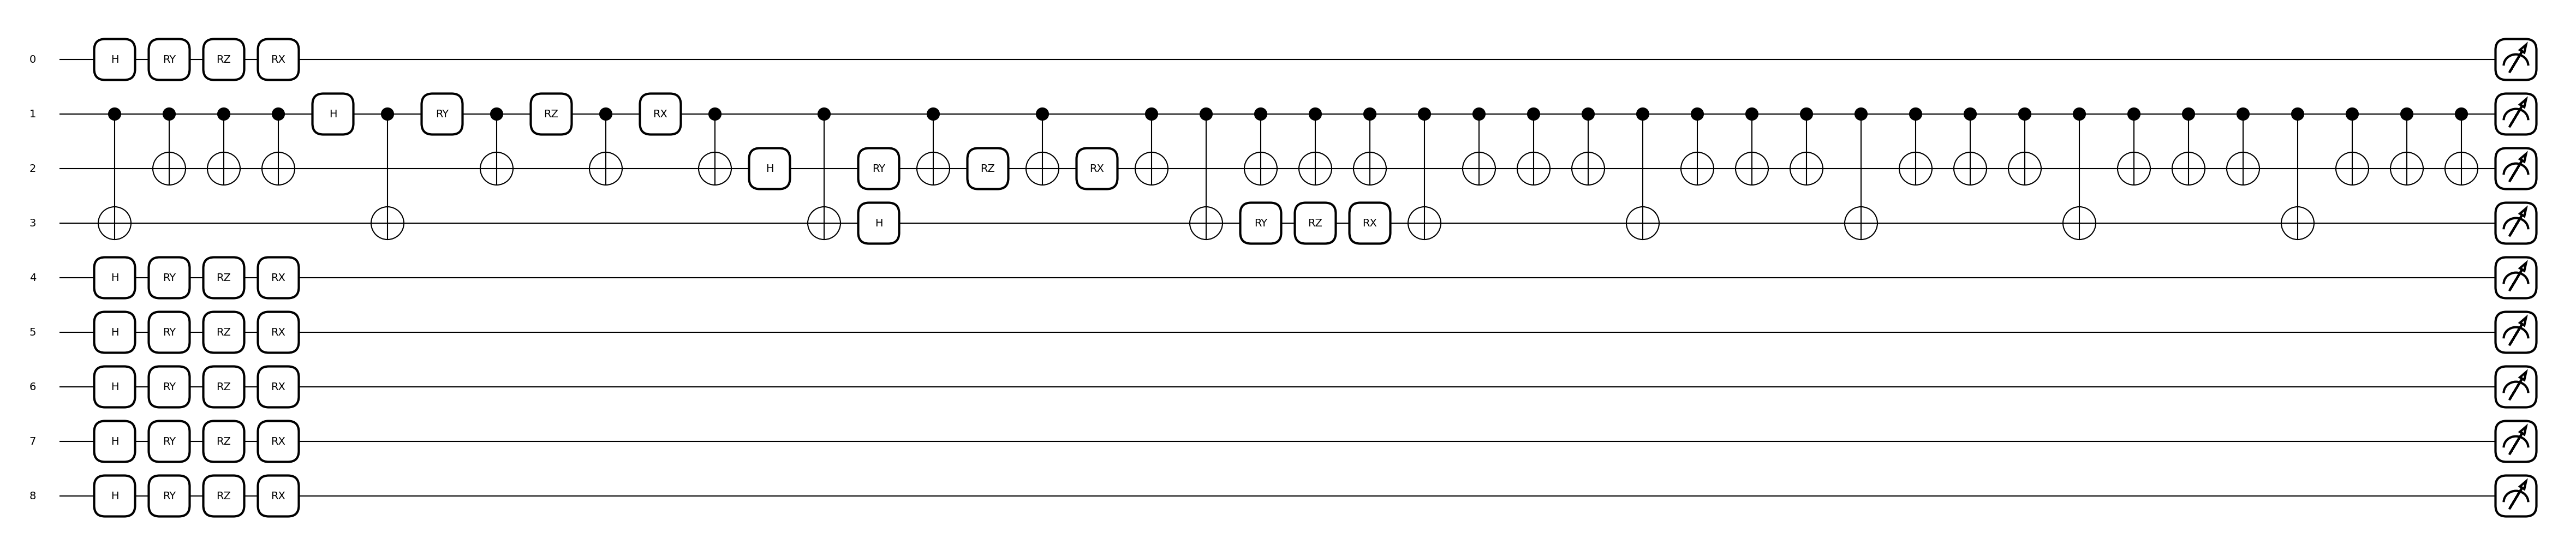

In [1]:
import pennylane as qml
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
# Sample training data
import lightgbm as lgb
import pandas as pd
import numpy as np
import pennylane as qml
from pennylane import numpy as np
from sklearn.svm import SVR



df=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\1002-ORIGIN-2D electronic properties2.csv",encoding='ISO-8859–1')      
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y = df['Band gap ']

# defining target
x=df[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]



# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x)

# Quantum setup
n_qubits = 9
dev = qml.device("default.qubit", wires=n_qubits)

# Define quantum feature map
def quantum_feature_map(x):
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.CNOT(wires=[1, 3])
        qml.RY(np.pi,wires=i)
        qml.CNOT(wires=[1, 2])
        qml.RZ(x[i % len(x)], wires=i)
        qml.CNOT(wires=[1, 2])
        qml.RX(np.pi*1.5, wires=i)
        qml.CNOT(wires=[1, 2])

# Define a quantum node
@qml.qnode(dev)
def circuit(x):
    quantum_feature_map(x)
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

# Visualize the quantum circuit for a sample
sample_x = X_train_scaled[0][:n_qubits]  # Take the first training sample, limit to `n_qubits`

# Draw the circuit using matplotlib
fig, ax = qml.draw_mpl(circuit)(sample_x)
plt.show()


In [13]:
df

,Formula,Heat of formation,Band gap,Area of unit-cell,Band gap (HSE06),Cond. band minimum,Energy above convex hull,Fermi level,Charge,Number of atoms,n-spins,Mass,Val. band maximum,Work function
0,O8Te4,-1.087,2.667,31.680,3.812,-1.551,0.000,-2.885,0,12,1,638.392,-4.218,4.728
1,Ru2F8,-1.855,0.628,26.731,2.286,-5.889,0.000,-6.203,0,10,2,354.127,-6.517,7.629
2,Al2MgS4,-1.181,2.048,11.968,3.143,-0.375,0.030,-1.399,0,7,1,206.508,-2.423,4.345
3,MnF12Sb2,-2.456,1.742,24.536,4.060,-4.044,0.000,-4.915,0,15,2,526.439,-5.786,7.100
4,Na4As4O8,-1.535,4.333,34.335,5.613,0.122,0.000,-2.045,0,16,1,519.637,-4.211,3.597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
997,K2H2O2,-1.356,2.867,15.711,4.501,-0.329,0.013,-1.762,0,6,1,112.211,-3.196,2.580
998,Rh2I2S2,-0.387,0.771,24.052,1.665,-2.327,0.049,-2.713,0,6,1,523.740,-3.098,4.722
999,H2O10Sb2Te2,-1.090,2.555,31.792,3.844,-2.988,0.084,-4.265,0,16,1,660.726,-5.542,6.378
1000,Mo2Zn2O12S2,-1.555,3.518,30.000,5.202,-2.351,0.090,-4.110,0,18,1,578.768,-5.869,6.441


In [2]:
y_train=(y)

In [3]:
# Quantum kernel function
@qml.qnode(dev)
def quantum_kernel(x1, x2):
    quantum_feature_map(x1)
    qml.adjoint(quantum_feature_map)(x2)
    return qml.probs(wires=range(n_qubits))
# Compute the kernel matrix for input data
def compute_kernel_matrix(X):
    n_samples = len(X)
    kernel_matrix = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        for j in range(n_samples):
            # Directly access the probability value (first element)
            kernel_matrix[i, j] = quantum_kernel(X[i], X[j])[0]
    return kernel_matrix
# Compute the quantum kernel matrix for training
K_train = compute_kernel_matrix(X_train_scaled)

# Train the SVR with a precomputed kernel matrix
svr = SVR(kernel='precomputed', epsilon=0.07491851902055541,C=977,gamma=2.0881963569756823)
svr.fit(K_train, y_train)



,kernel,'precomputed'
,degree,3
,gamma,2.0881963569756823
,coef0,0.0
,tol,0.001
,C,977
,epsilon,0.07491851902055541
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


train r^2: 0.9983887671509591
train MAE 0.048859389610353604
train RMSE: 0.05539574119206048


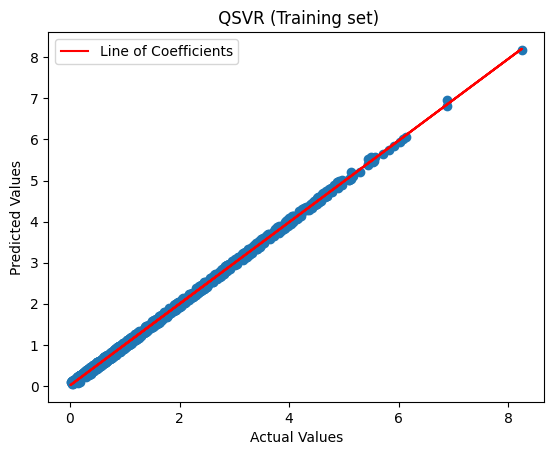

In [4]:
y_predtrain= svr.predict(K_train)
import numpy as np
from sklearn.ensemble import *
from sklearn.metrics import *
from sklearn.model_selection import *
import pandas as pd
## lgbm optimization
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn import ensemble
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
print('train r^2:',r2_score(y_train,y_predtrain))
print('train MAE', mean_absolute_error(y_train,y_predtrain))
print('train RMSE:',np.sqrt(mean_squared_error(y_train,y_predtrain)))
# Plot straight line
plt.scatter(y_train,y_predtrain)
coefficients = np.polyfit(y_train,y_predtrain, 1)
line = np.polyval(coefficients, y_train)
plt.plot(y_train, line, color='r', label='Line of Coefficients')
# Plot straight line
plt.plot(y_train, line, color='r',)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y_train,y_predtrain)), (-0.2, 20.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y_train,y_predtrain)), (-0.2, 18.2))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y_train,y_predtrain))), (-0.2, 16.0))
plt.title(" QSVR (Training set)")#title
plt.legend()

In [5]:
df_true50=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-50-EXTERNAL DATA.csv",encoding='ISO-8859–1')    
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y2 = df_true50['Band gap ']

# defining target
x2=df_true50[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test2= scaler.transform(x2)

# Compute the test kernel matrix (train-test kernel)
K_test2 = np.zeros((len(x_test2), len(X_train_scaled)))
for i in range(len(x_test2)):
    for j in range(len(X_train_scaled)):
        K_test2[i, j] = quantum_kernel(x_test2[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred2 = svr.predict(K_test2)
print("Predicted values:", y_pred2)

Predicted values: [1.58722022 1.3698216  0.93528832 0.54459586 1.8477685  1.33293515
 1.04054787 0.55681828 2.95627534 3.01731592 0.22409248 2.78884879
 2.38911358 0.49305427 1.35503747 0.55982856 0.60310138 3.06044265
 0.25628038 2.9467241  1.06023031 2.68544988 1.26517866 2.74218567
 1.9156876  0.86411225 2.07615193 1.57280224 2.37648977 2.52012039
 3.38986058 0.66061405 0.98712265 0.9718139  1.48596159 1.14038761
 0.32698471 4.34015368 3.27716444 0.30309424 2.64244815 3.99239038
 0.67818165 0.42200657 0.68556819 0.74426376 1.48050872 2.34138371
 0.47608553 3.8453235 ]


In [19]:
df_true50

,Formula,Heat of formation,Band gap,Area of unit-cell,Band gap (HSE06),Cond. band minimum,Energy above convex hull,Fermi level,Charge,Number of atoms,n-spins,Mass,Val. band maximum,Work function
0,P4Si4Te4,-0.067,1.524,49.737,2.239,-1.725,0.035,-2.487,0,12,1,746.635,-3.249,4.289
1,Sb4Si4Te4,0.014,1.360,59.630,1.966,-1.759,0.083,-2.439,0,12,1,1109.780,-3.119,4.199
2,CrHS2,-0.447,1.115,11.054,2.800,-1.843,0.078,-2.401,0,4,2,117.124,-2.958,4.112
3,CuAs2SbSe6,-0.060,0.509,39.605,1.257,-3.077,0.098,-3.331,0,10,1,808.975,-3.586,5.304
4,Li4S8Sb4,-0.671,1.855,40.747,2.746,-1.301,0.011,-2.228,0,16,1,771.280,-3.155,4.387
5,AgAlP2Se6,-0.316,1.366,35.640,2.339,-2.057,0.000,-2.741,0,10,1,670.623,-3.424,4.773
6,Sn2Zr2S8,-0.954,1.072,39.728,1.937,-2.390,0.043,-2.926,0,12,1,676.348,-3.462,4.956
7,AgVP2S6,-0.381,0.371,32.087,2.054,-3.151,0.008,-3.336,0,10,2,413.117,-3.521,5.358
8,AlNaP2S6,-0.642,2.952,37.502,3.965,-1.908,0.000,-3.384,0,10,1,304.279,-4.860,5.035
9,BiHO6Te2,-1.129,2.979,21.235,4.226,-1.307,0.024,-2.796,0,10,1,561.182,-4.286,4.810


Model evaluation - Test Set:
r^2: 0.9396310645182314
MAE 0.14449786013522053
RMSE: 0.31001149820821355


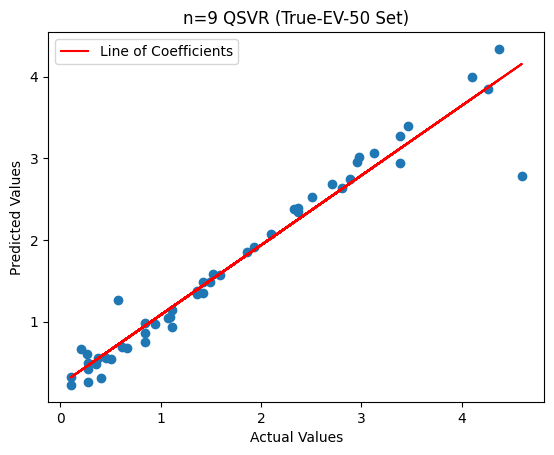

In [6]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y2, y_pred2))
print('MAE', mean_absolute_error(y2, y_pred2))
print('RMSE:',np.sqrt(mean_squared_error(y2, y_pred2)))
# Plot straight line
plt.scatter(y2, y_pred2)
coefficients = np.polyfit(y2, y_pred2, 1)
line = np.polyval(coefficients, y2)
plt.plot(y2, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y2, y_pred2)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y2, y_pred2))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y2, y_pred2)), (-0.2, 13.2))
plt.title("n=9 QSVR (True-EV-50 Set)")#title
plt.legend()

In [7]:
df3=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-100-EXTERNAL DATA.csv",encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y3 = df3['Band gap ']

# defining target
x3=df3[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test3= scaler.transform(x3)

# Compute the test kernel matrix (train-test kernel)
K_test3 = np.zeros((len(x_test3), len(X_train_scaled)))
for i in range(len(x_test3)):
    for j in range(len(X_train_scaled)):
        K_test3[i, j] = quantum_kernel(x_test3[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred3 = svr.predict(K_test3)
print("Predicted values:", y_pred3)

Predicted values: [2.29207746 4.85919453 3.64193063 1.30038533 5.18089007 2.89383377
 5.12994725 1.88575079 0.63641168 0.72617756 0.33490457 0.46618053
 0.30770004 0.57349414 0.0610264  2.29927153 0.58198241 0.63511071
 2.15670795 2.31852224 2.72633404 0.15615122 1.14531062 1.94907222
 0.68395048 0.85939795 3.85526214 5.33835324 2.05964885 2.56302267
 4.04263062 5.98444856 4.1444477  1.77425888 1.9201883  0.15035031
 0.80600225 1.45010414 0.97220987 3.54338724 0.99533964 0.90212782
 0.47030865 1.21749817 2.09955715 1.35024273 1.33801025 0.34992827
 1.16264942 1.71386651 0.52105986 0.85870337 0.16629943 0.66203533
 0.25815399 1.27887283 2.31070526 0.90255254 0.77713604 5.84868057
 6.01795724 0.9887499  1.08341983 1.89795893 1.48255171 2.59605244
 4.42801835 1.94154248 1.5451705  3.47697045 0.46568303 3.86971375
 1.09413263 1.90582864 0.93371403 4.50004953 2.6445727  0.90620602
 1.80971336 1.12963559 0.61742422 0.45424029 0.66043701 1.88284392
 0.69038281 0.78649456 2.46610075 1.23700487

Model evaluation - Test Set:
r^2: 0.9865299194649709
MAE 0.10721355695649493
RMSE: 0.1840598294862284


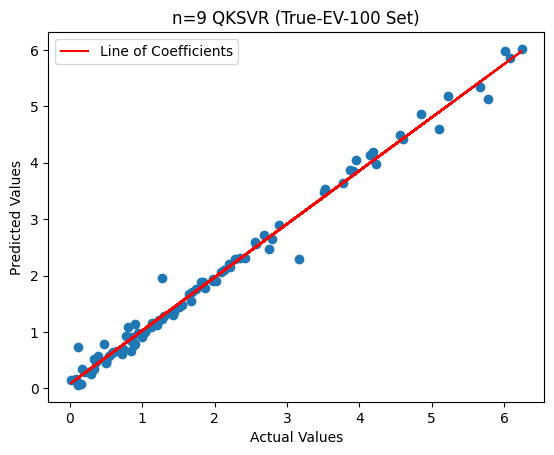

In [8]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y3, y_pred3))
print('MAE', mean_absolute_error(y3, y_pred3))
print('RMSE:',np.sqrt(mean_squared_error(y3, y_pred3)))
# Plot straight line
plt.scatter(y3, y_pred3)
coefficients = np.polyfit(y3, y_pred3, 1)
line = np.polyval(coefficients, y3)
plt.plot(y3, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y3, y_pred3)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y3, y_pred3))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y3, y_pred3)), (-0.2, 13.2))
plt.title("n=9 QKSVR (True-EV-100 Set)")#title
plt.legend()

In [15]:
df3

,Formula,Heat of formation,Band gap,Area of unit-cell,Band gap (HSE06),Cond. band minimum,Energy above convex hull,Fermi level,Charge,Number of atoms,n-spins,Mass,Val. band maximum,Work function
0,MnF12P2,-2.614,3.162,21.908,6.441,-2.972,0.000,-4.553,0,15,2,344.866,-6.134,6.626
1,SrF12Sb2,-2.799,4.846,23.263,7.220,-3.209,0.000,-5.632,0,15,1,559.121,-8.055,8.210
2,BaH2S2,-0.966,3.774,21.887,4.778,0.605,0.015,-1.282,0,5,1,203.463,-3.169,3.323
3,Ta2F4S4,-1.925,1.420,28.063,2.327,-1.986,0.058,-2.695,0,10,1,566.129,-3.405,4.536
4,Ca2Cl4H8S4,-0.922,5.219,47.904,6.475,-0.597,0.009,-3.206,0,18,1,358.260,-5.816,4.646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Sc2As2Se6,-0.851,0.839,39.604,1.299,-0.890,0.000,-1.310,0,10,1,713.581,-1.729,4.843
96,Nb4Ni6S10,-0.752,0.150,58.655,0.009,-2.845,0.039,-2.920,0,20,1,1044.386,-2.995,5.061
97,O9P2Si3,-2.290,5.102,41.105,6.548,-0.502,0.098,-3.053,0,14,1,290.194,-5.604,4.285
98,Ta3Br8,-0.865,0.213,43.925,0.821,-2.106,0.057,-2.212,0,11,2,1182.076,-2.318,4.107


In [9]:

df4=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-250-EXTERNAL DATA.csv",encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y4 = df4['Band gap ']

# defining target
x4=df4[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test4= scaler.transform(x4)

# Compute the test kernel matrix (train-test kernel)
K_test4 = np.zeros((len(x_test4), len(X_train_scaled)))
for i in range(len(x_test4)):
    for j in range(len(X_train_scaled)):
        K_test4[i, j] = quantum_kernel(x_test4[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred4 = svr.predict(K_test4)
print("Predicted values:", y_pred4)

Predicted values: [1.09496256 4.84262349 3.27016756 0.63751404 3.26833771 2.38713547
 2.61872598 0.81707515 0.91020872 5.25608073 0.35689141 5.29737244
 3.36296922 0.40802584 0.27541449 0.16085289 4.41513446 0.63080051
 0.61774701 2.57951549 4.21369931 0.32079132 5.53148293 1.48059509
 0.9532563  0.90928044 3.21255766 2.31844905 2.09313205 1.71751016
 1.09369868 1.28427255 0.84644043 0.69324483 0.82276611 1.40651449
 1.42954278 1.38783576 1.66433242 3.20092352 0.7450829  0.82057642
 0.43566764 0.9534967  0.86890402 3.88939292 0.44653942 0.89979133
 1.61049356 0.70621034 0.67576541 1.49526236 0.43630493 0.76281197
 0.78562402 2.40445993 1.01257432 1.07739695 0.89269966 1.33876908
 0.61623506 0.91177156 2.42580414 0.73211531 0.73977489 1.09109026
 0.84858371 0.96804735 4.26782402 1.62206794 0.33653205 4.00268801
 1.46866242 1.55811044 0.23764547 0.67542315 0.33646782 0.78610642
 0.64346098 1.21446758 2.31779669 0.51218811 2.48792315 1.16262296
 1.82040101 1.20699769 1.01804063 3.9017365 

Model evaluation - Test Set:
r^2: 0.9652123335349732
MAE 0.11878739782834555
RMSE: 0.27284846235019067


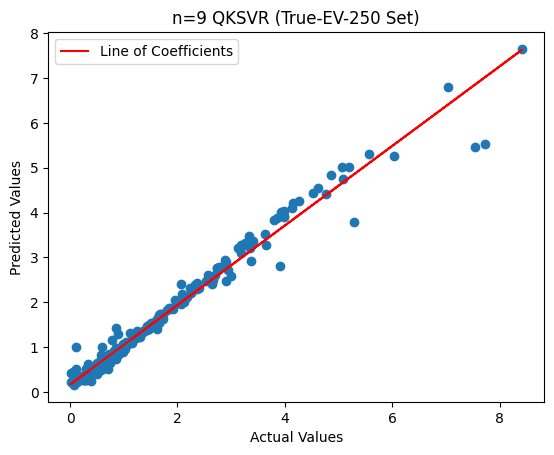

In [10]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y4, y_pred4))
print('MAE', mean_absolute_error(y4, y_pred4))
print('RMSE:',np.sqrt(mean_squared_error(y4, y_pred4)))
# Plot straight line
plt.scatter(y4, y_pred4)
coefficients = np.polyfit(y4, y_pred4, 1)
line = np.polyval(coefficients, y4)
plt.plot(y4, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y4, y_pred4)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y4, y_pred4))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y4, y_pred4)), (-0.2, 13.2))
plt.title("n=9 QKSVR (True-EV-250 Set)")#title
plt.legend()

In [16]:
df4

,Formula,Heat of formation,Band gap,Area of unit-cell,Band gap (HSE06),Cond. band minimum,Energy above convex hull,Fermi level,Charge,Number of atoms,n-spins,Mass,Val. band maximum,Work function
0,Pd4Br8,-0.375,1.148,58.771,2.370,-3.763,0.000,-4.337,0,12,1,1064.912,-4.911,5.659
1,BaAs2F12,-2.641,4.852,23.366,7.286,-3.188,0.000,-5.614,0,15,1,515.151,-8.040,8.150
2,BaH2Se2,-0.820,3.220,23.830,4.158,0.356,0.030,-1.254,0,5,1,297.285,-2.864,3.397
3,Sc2Br2C,-1.327,0.663,10.724,1.736,-2.116,0.000,-2.447,0,5,1,261.731,-2.779,5.181
4,SrH2Se2,-0.797,3.192,21.030,4.146,0.188,0.031,-1.408,0,5,1,247.578,-3.004,3.453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,Bi2Hg2I2O4,-0.787,1.680,33.299,2.659,-2.107,0.012,-2.947,0,10,1,1136.950,-3.787,4.875
246,Sr4F4P4Se8,-1.660,1.648,34.673,2.397,-0.789,0.055,-1.613,0,20,1,1182.137,-2.437,4.943
247,Cs2C2H6O6S2,-1.065,4.520,31.932,6.116,0.466,0.096,-1.794,0,18,1,455.995,-4.054,3.204
248,Sn2C2H6S6Sb2,-0.175,1.627,49.330,2.426,-1.962,0.088,-2.776,0,18,1,703.370,-3.590,4.255


In [11]:
df5=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-400-EXTERNAL DATA.csv",encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y5 = df5['Band gap ']

# defining target
x5=df5[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test5= scaler.transform(x5)

# Compute the test kernel matrix (train-test kernel)
K_test5 = np.zeros((len(x_test5), len(X_train_scaled)))
for i in range(len(x_test5)):
    for j in range(len(X_train_scaled)):
        K_test5[i, j] = quantum_kernel(x_test5[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred5 = svr.predict(K_test5)
print("Predicted values:", y_pred5)

Predicted values: [1.58722022 1.3698216  0.93528832 0.54459586 1.8477685  1.33293515
 1.04054787 0.55681828 2.95627534 3.01731592 0.22409248 2.78884879
 2.38911358 0.49305427 1.35503747 0.55982856 0.60310138 3.06044265
 0.25628038 2.9467241  1.06023031 2.68544988 1.26517866 2.74218567
 1.9156876  0.86411225 2.07615193 1.57280224 2.37648977 2.52012039
 3.38986058 0.66061405 0.98712265 0.9718139  1.48596159 1.14038761
 0.32698471 4.34015368 3.27716444 0.30309424 2.64244815 3.99239038
 0.67818165 0.42200657 0.68556819 0.74426376 1.48050872 2.34138371
 0.47608553 3.8453235  2.29207746 4.85919453 3.64193063 1.30038533
 5.18089007 2.89383377 5.12994725 1.88575079 0.63641168 0.72617756
 0.33490457 0.46618053 0.30770004 0.57349414 0.0610264  2.29927153
 0.58198241 0.63511071 2.15670795 2.31852224 2.72633404 0.15615122
 1.14531062 1.94907222 0.68395048 0.85939795 3.85526214 5.33835324
 2.05964885 2.56302267 4.04263062 5.98444856 4.1444477  1.77425888
 1.9201883  0.15035031 0.80600225 1.45010414

In [17]:
df5

,Formula,Heat of formation,Band gap,Area of unit-cell,Band gap (HSE06),Cond. band minimum,Energy above convex hull,Fermi level,Charge,Number of atoms,n-spins,Mass,Val. band maximum,Work function
0,P4Si4Te4,-0.067,1.524,49.737,2.239,-1.725,0.035,-2.487,0,12,1,746.635,-3.249,4.289
1,Sb4Si4Te4,0.014,1.360,59.630,1.966,-1.759,0.083,-2.439,0,12,1,1109.780,-3.119,4.199
2,CrHS2,-0.447,1.115,11.054,2.800,-1.843,0.078,-2.401,0,4,2,117.124,-2.958,4.112
3,CuAs2SbSe6,-0.060,0.509,39.605,1.257,-3.077,0.098,-3.331,0,10,1,808.975,-3.586,5.304
4,Li4S8Sb4,-0.671,1.855,40.747,2.746,-1.301,0.011,-2.228,0,16,1,771.280,-3.155,4.387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,Bi2Hg2I2O4,-0.787,1.680,33.299,2.659,-2.107,0.012,-2.947,0,10,1,1136.950,-3.787,4.875
396,Sr4F4P4Se8,-1.660,1.648,34.673,2.397,-0.789,0.055,-1.613,0,20,1,1182.137,-2.437,4.943
397,Cs2C2H6O6S2,-1.065,4.520,31.932,6.116,0.466,0.096,-1.794,0,18,1,455.995,-4.054,3.204
398,Sn2C2H6S6Sb2,-0.175,1.627,49.330,2.426,-1.962,0.088,-2.776,0,18,1,703.370,-3.590,4.255


Model evaluation - Test Set:
r^2: 0.969189737986074
MAE 0.11910774539874225
RMSE: 0.2588664201177456


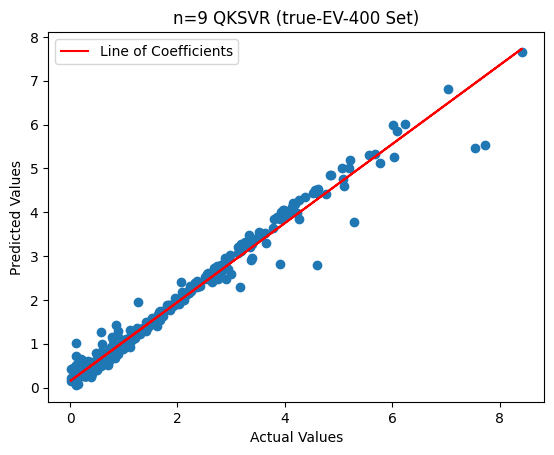

In [12]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y5, y_pred5))
print('MAE', mean_absolute_error(y5, y_pred5))
print('RMSE:',np.sqrt(mean_squared_error(y5, y_pred5)))
# Plot straight line
plt.scatter(y5, y_pred5)
coefficients = np.polyfit(y5, y_pred5, 1)
line = np.polyval(coefficients, y5)
plt.plot(y5, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y5, y_pred5)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y5, y_pred5))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y5, y_pred5)), (-0.2, 13.2))
plt.title("n=9 QKSVR (true-EV-400 Set)")#title
plt.legend()